In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import load_features
from src.models import (
    build_svm, build_lda, build_rf,
    evaluate_model, save_model,
    save_metrics, run_all_visualizations
)

In [3]:
subjects      = ['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']
FEATURES_PATH = '../data/features/'
MODELS_PATH   = '../results/models/baseline/'
METRICS_PATH  = '../results/metrics/baseline/'
FIGURES_PATH  = '../results/figures/training/baseline/'
CLASS_NAMES   = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

In [4]:
all_results = {}

for subject_id in subjects:
    print(f"\n{'='*50}")
    print(f"  {subject_id}")
    print(f"{'='*50}")

    X, y = load_features(subject_id, load_path=FEATURES_PATH)

    models = {
        'SVM': build_svm(),
        'LDA': build_lda(),
        'RF':  build_rf()
    }

    all_results[subject_id] = {}

    for model_name, model in models.items():
        print(f"\n  Training {model_name}...")
        result = evaluate_model(model, X, y)
        print(f"  Accuracy: {result['mean']*100:.1f}% (+/- {result['std']*100:.1f}%)")
        print(f"  Per fold: {np.round(result['scores']*100, 1)}")

        model.fit(X, y)
        save_model(model, subject_id, model_name, save_path=MODELS_PATH)
        all_results[subject_id][model_name] = result

print("\nAll subjects done.")


  A01T
Loaded features for A01T: X=(164, 8), y=(164,)

  Training SVM...
  Accuracy: 84.2% (+/- 4.4%)
  Per fold: [78.8 81.8 81.8 87.9 90.6]
Model saved to ../results/models/baseline/A01T_SVM.pkl

  Training LDA...
  Accuracy: 83.5% (+/- 6.2%)
  Per fold: [72.7 87.9 81.8 90.9 84.4]
Model saved to ../results/models/baseline/A01T_LDA.pkl

  Training RF...
  Accuracy: 81.1% (+/- 3.4%)
  Per fold: [75.8 81.8 78.8 84.8 84.4]
Model saved to ../results/models/baseline/A01T_RF.pkl

  A02T
Loaded features for A02T: X=(216, 8), y=(216,)

  Training SVM...
  Accuracy: 58.8% (+/- 3.3%)
  Per fold: [56.8 60.5 60.5 53.5 62.8]
Model saved to ../results/models/baseline/A02T_SVM.pkl

  Training LDA...
  Accuracy: 60.2% (+/- 2.6%)
  Per fold: [59.1 65.1 58.1 58.1 60.5]
Model saved to ../results/models/baseline/A02T_LDA.pkl

  Training RF...
  Accuracy: 58.8% (+/- 6.0%)
  Per fold: [54.5 55.8 60.5 53.5 69.8]
Model saved to ../results/models/baseline/A02T_RF.pkl

  A03T
Loaded features for A03T: X=(179, 

In [5]:
# Save all metrics to CSV files
acc_df, f1_df, fold_df = save_metrics(all_results, subjects, save_path=METRICS_PATH)

Saved accuracy_summary.csv
Saved per_class_metrics.csv
Saved per_fold_scores.csv


In [6]:
# Print accuracy summary table
print("ACCURACY SUMMARY")
print("="*70)
rows = []
for subject_id in subjects:
    row = {'Subject': subject_id}
    for model_name in ['SVM', 'LDA', 'RF']:
        mean = all_results[subject_id][model_name]['mean']
        std  = all_results[subject_id][model_name]['std']
        row[model_name] = f"{mean*100:.1f}% (+/-{std*100:.1f}%)"
    rows.append(row)

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

print()
print("AVERAGE ACROSS ALL SUBJECTS")
print("-"*40)
for model_name in ['SVM', 'LDA', 'RF']:
    avg = np.mean([all_results[s][model_name]['mean'] for s in subjects])
    std = np.std([all_results[s][model_name]['mean'] for s in subjects])
    print(f"  {model_name}: {avg*100:.1f}% (+/- {std*100:.1f}%)")
print(f"  Chance level: 25.0%")

ACCURACY SUMMARY
Subject             SVM             LDA               RF
   A01T 84.2% (+/-4.4%) 83.5% (+/-6.2%)  81.1% (+/-3.4%)
   A02T 58.8% (+/-3.3%) 60.2% (+/-2.6%)  58.8% (+/-6.0%)
   A03T 87.7% (+/-3.8%) 86.0% (+/-5.0%)  87.7% (+/-3.0%)
   A04T 55.4% (+/-2.3%) 57.6% (+/-5.9%)  54.2% (+/-5.9%)
   A05T 54.3% (+/-4.2%) 55.1% (+/-1.1%)  57.5% (+/-5.8%)
   A06T 53.6% (+/-3.7%) 55.7% (+/-3.1%)  49.7% (+/-4.2%)
   A07T 82.2% (+/-4.1%) 81.4% (+/-9.0%) 76.6% (+/-11.5%)
   A08T 87.2% (+/-4.9%) 87.6% (+/-5.2%)  83.8% (+/-4.0%)
   A09T 62.6% (+/-5.6%) 65.0% (+/-8.5%)  62.0% (+/-5.8%)

AVERAGE ACROSS ALL SUBJECTS
----------------------------------------
  SVM: 69.5% (+/- 14.4%)
  LDA: 70.2% (+/- 13.2%)
  RF: 67.9% (+/- 13.5%)
  Chance level: 25.0%


In [7]:
# Best and worst subjects
print("BEST MODEL PER SUBJECT")
print("-"*40)
for subject_id in subjects:
    accs       = {m: all_results[subject_id][m]['mean'] for m in ['SVM', 'LDA', 'RF']}
    best_model = max(accs, key=accs.get)
    worst_model = min(accs, key=accs.get)
    print(f"  {subject_id}: best={best_model} ({accs[best_model]*100:.1f}%)  worst={worst_model} ({accs[worst_model]*100:.1f}%)")

print()
best_overall  = max(subjects, key=lambda s: all_results[s]['SVM']['mean'])
worst_overall = min(subjects, key=lambda s: all_results[s]['SVM']['mean'])
print(f"Best overall subject (SVM):  {best_overall} — {all_results[best_overall]['SVM']['mean']*100:.1f}%")
print(f"Worst overall subject (SVM): {worst_overall} — {all_results[worst_overall]['SVM']['mean']*100:.1f}%")

BEST MODEL PER SUBJECT
----------------------------------------
  A01T: best=SVM (84.2%)  worst=RF (81.1%)
  A02T: best=LDA (60.2%)  worst=SVM (58.8%)
  A03T: best=SVM (87.7%)  worst=LDA (86.0%)
  A04T: best=LDA (57.6%)  worst=RF (54.2%)
  A05T: best=RF (57.5%)  worst=SVM (54.3%)
  A06T: best=LDA (55.7%)  worst=RF (49.7%)
  A07T: best=SVM (82.2%)  worst=RF (76.6%)
  A08T: best=LDA (87.6%)  worst=RF (83.8%)
  A09T: best=LDA (65.0%)  worst=RF (62.0%)

Best overall subject (SVM):  A03T — 87.7%
Worst overall subject (SVM): A06T — 53.6%



Generating all training visualizations...


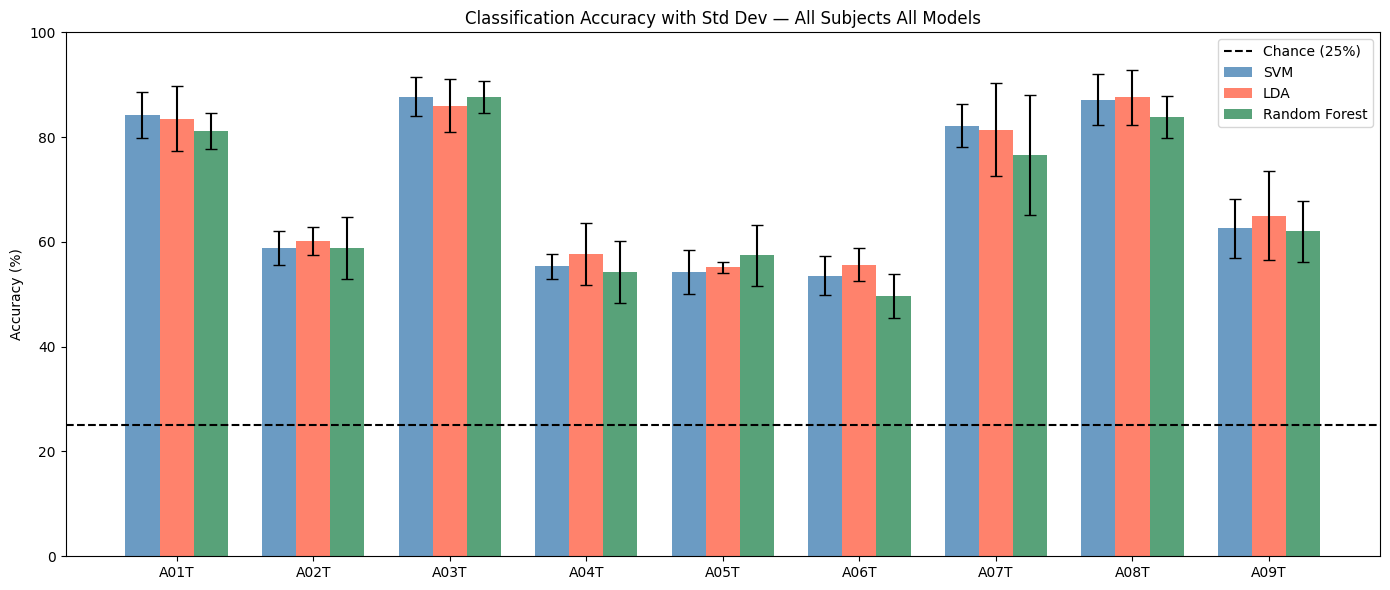

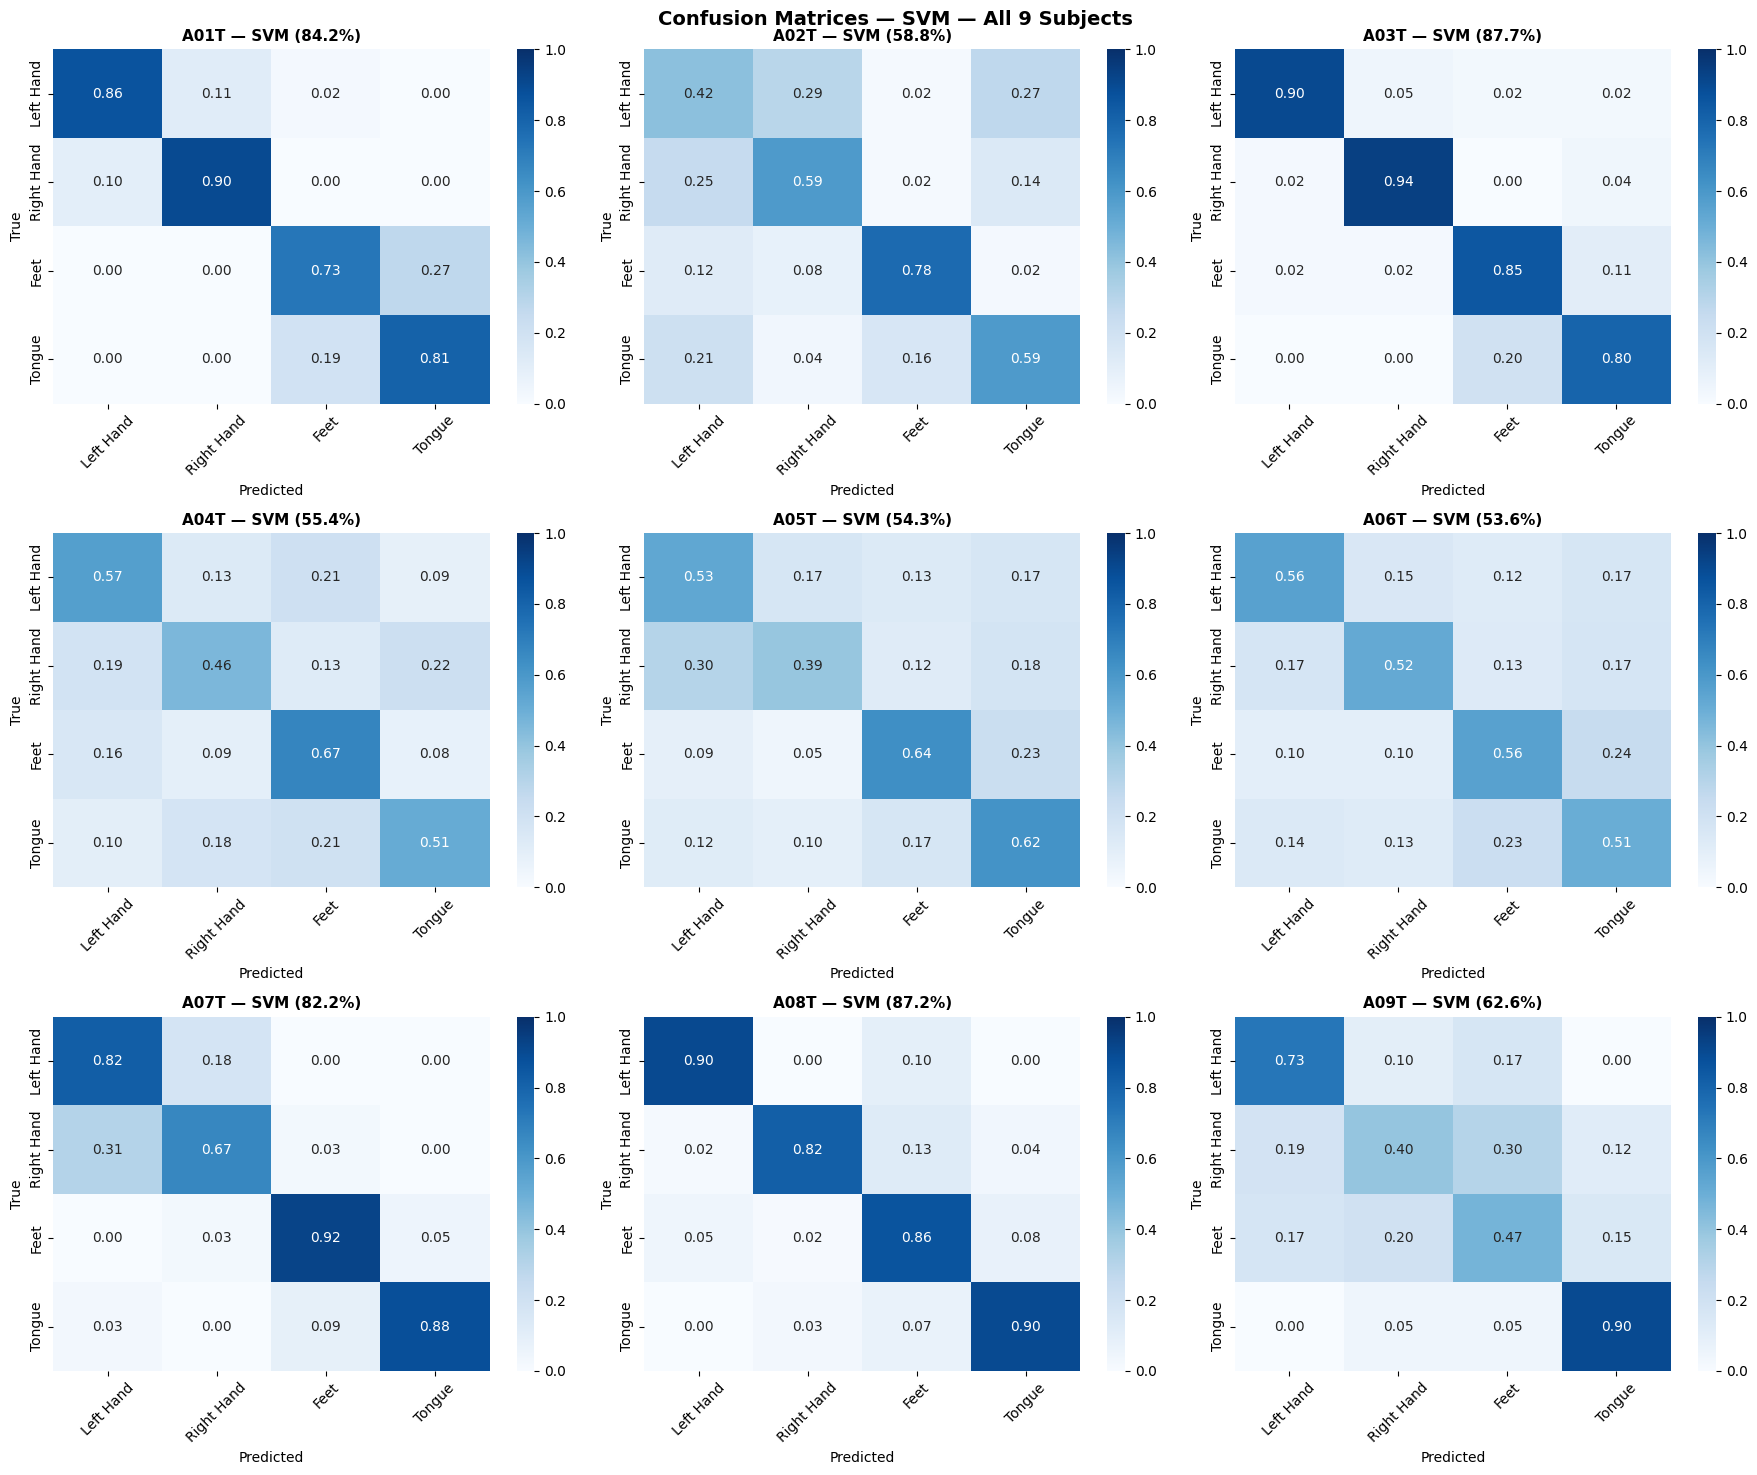

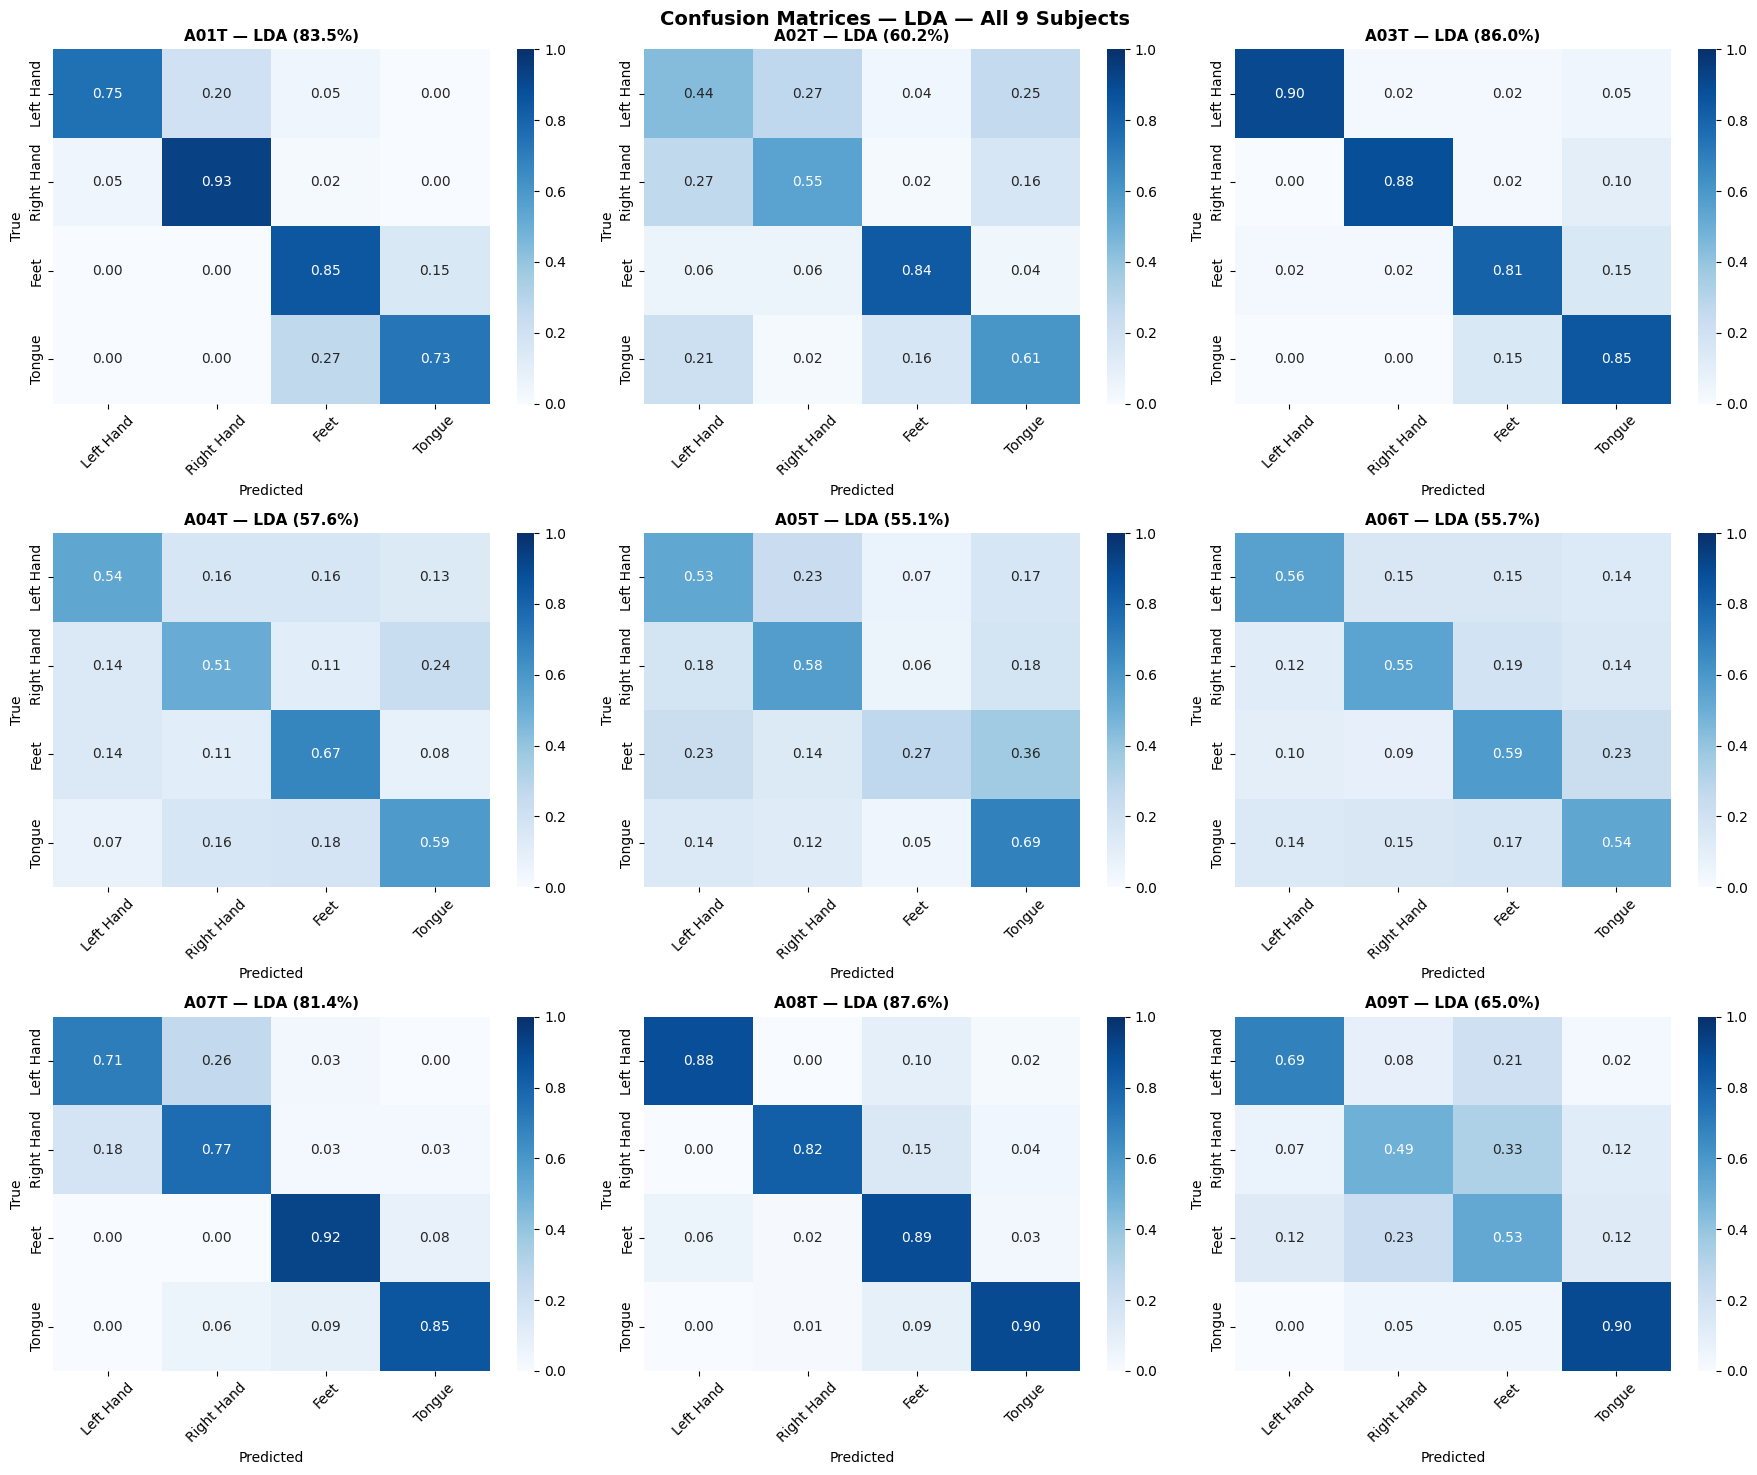

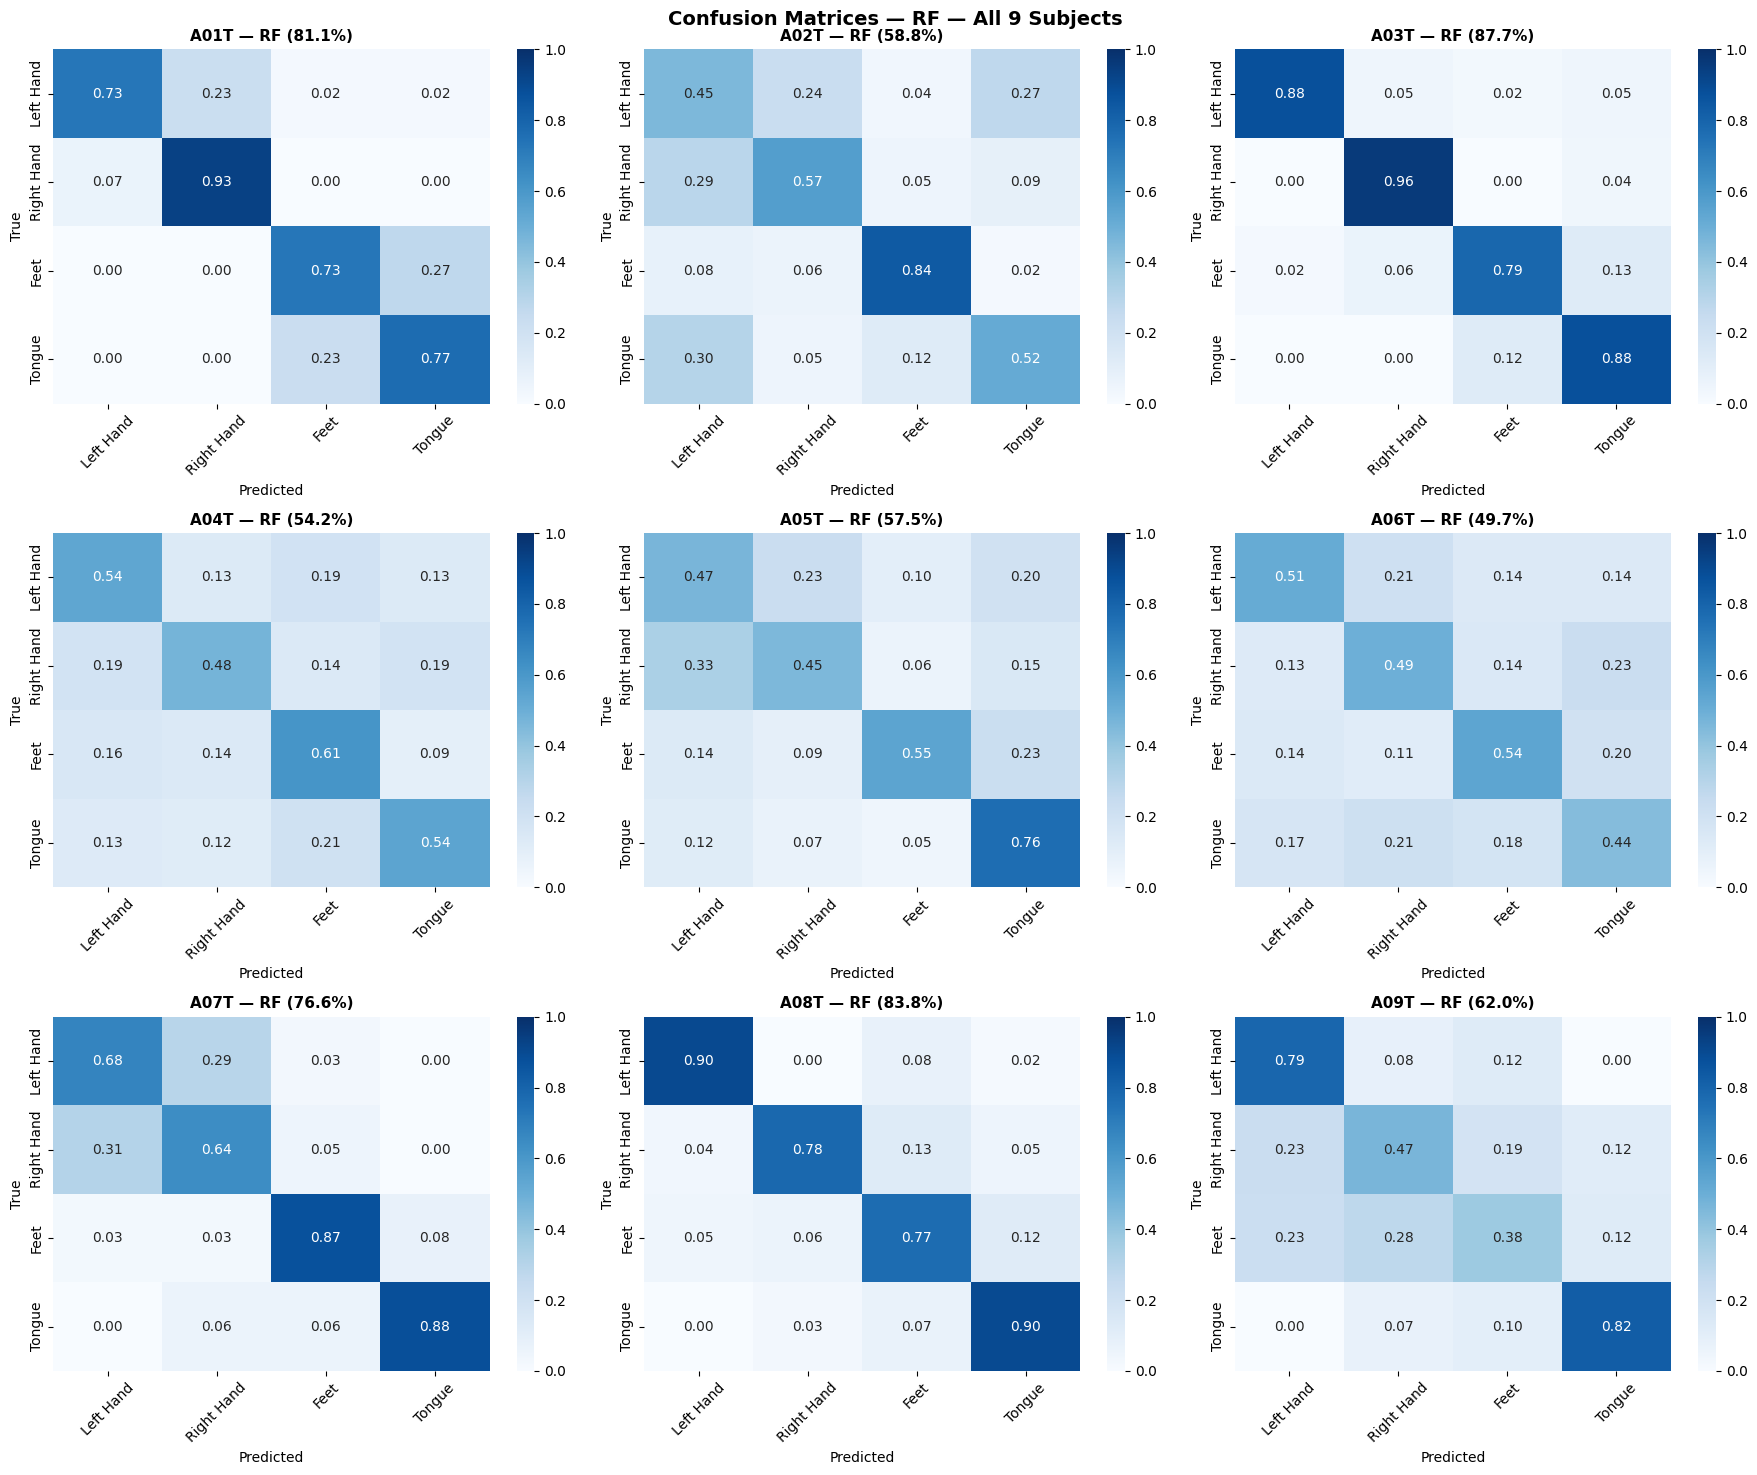

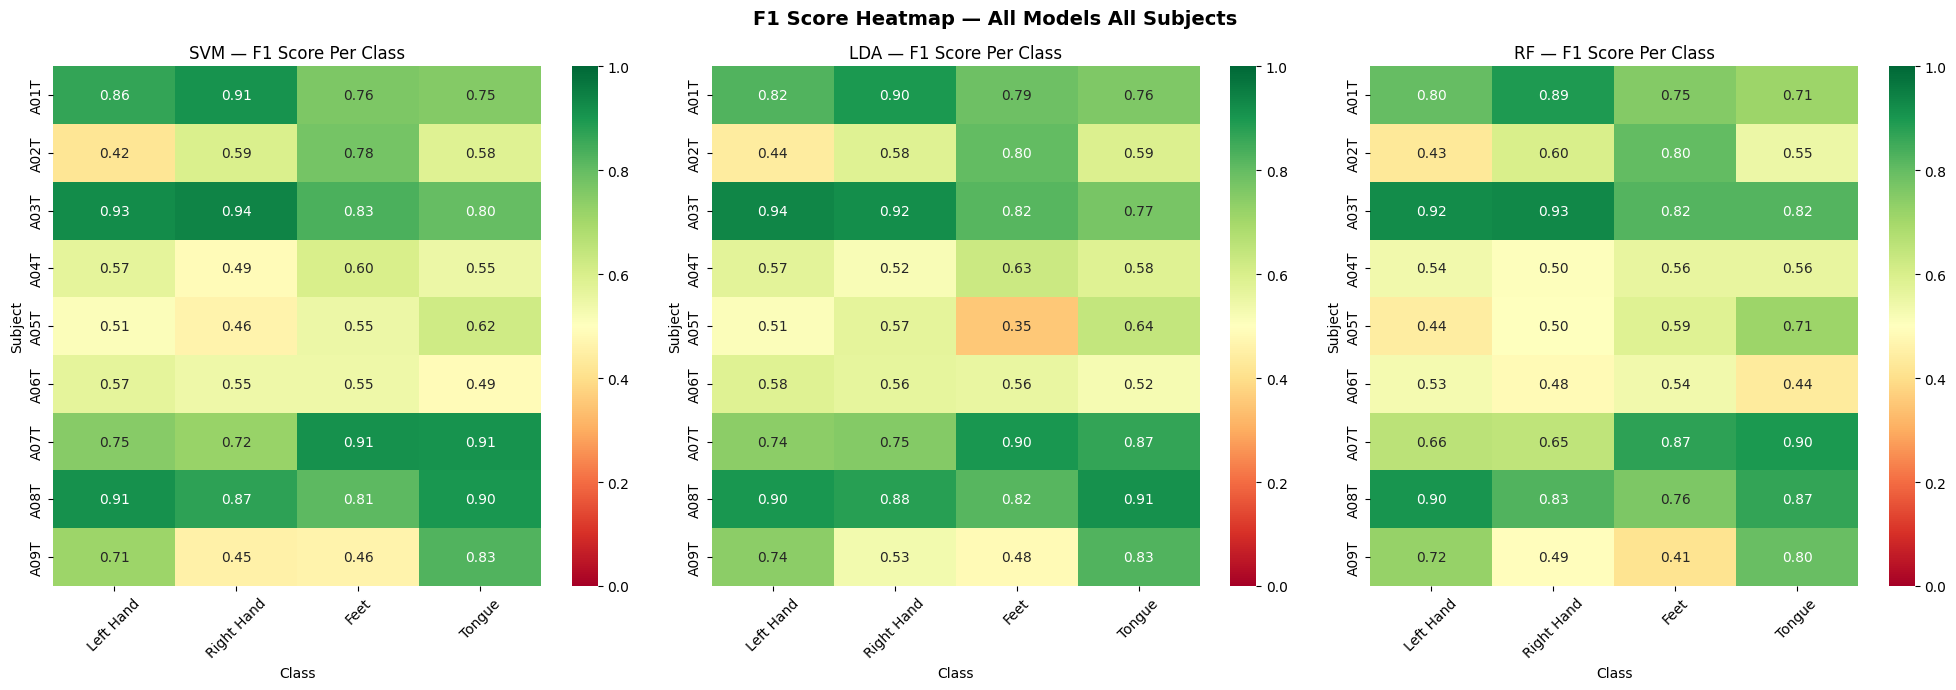

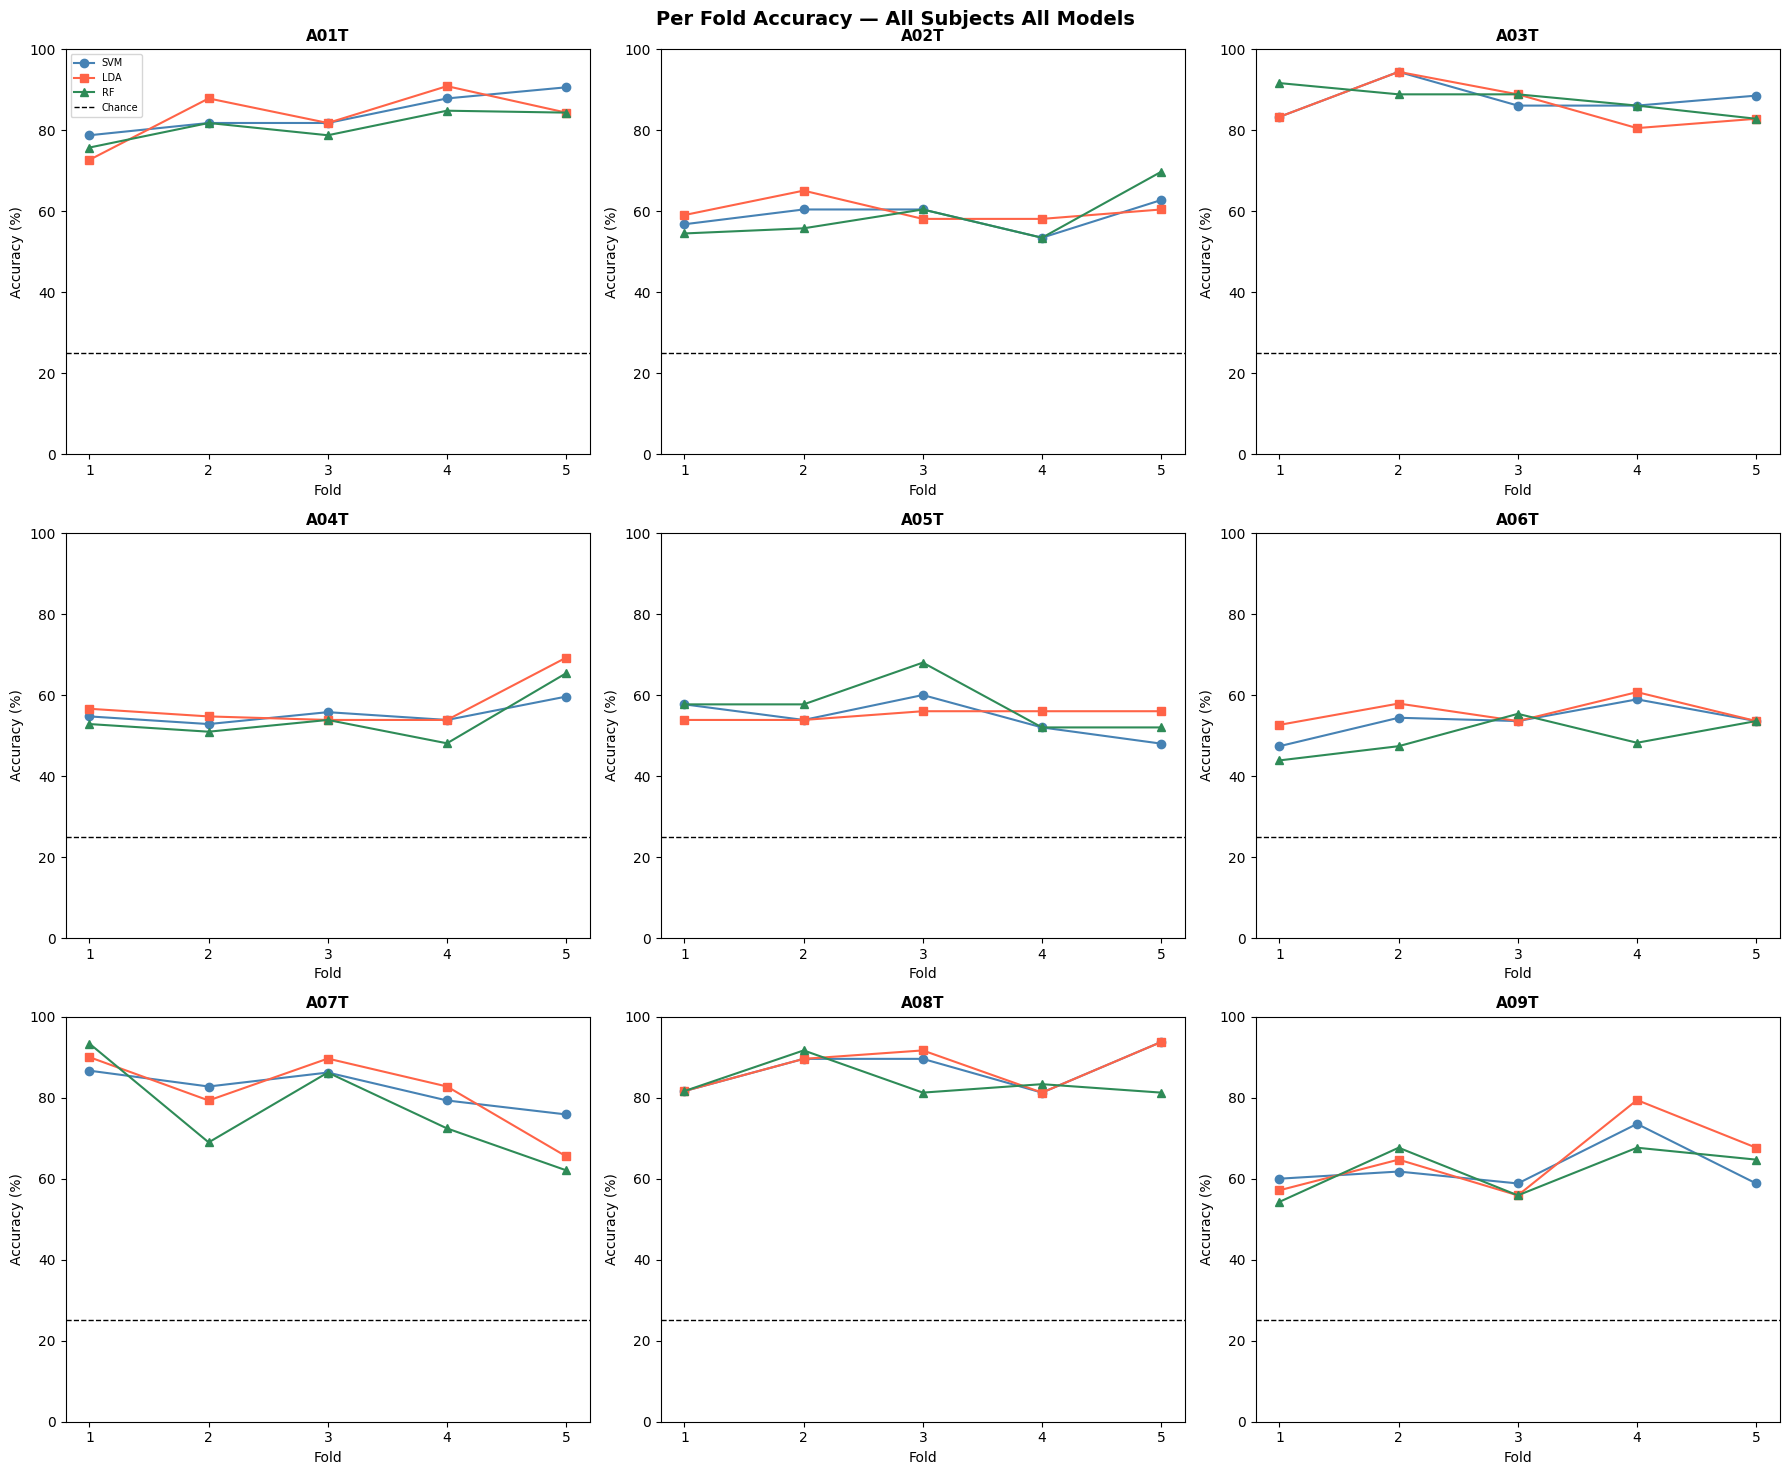

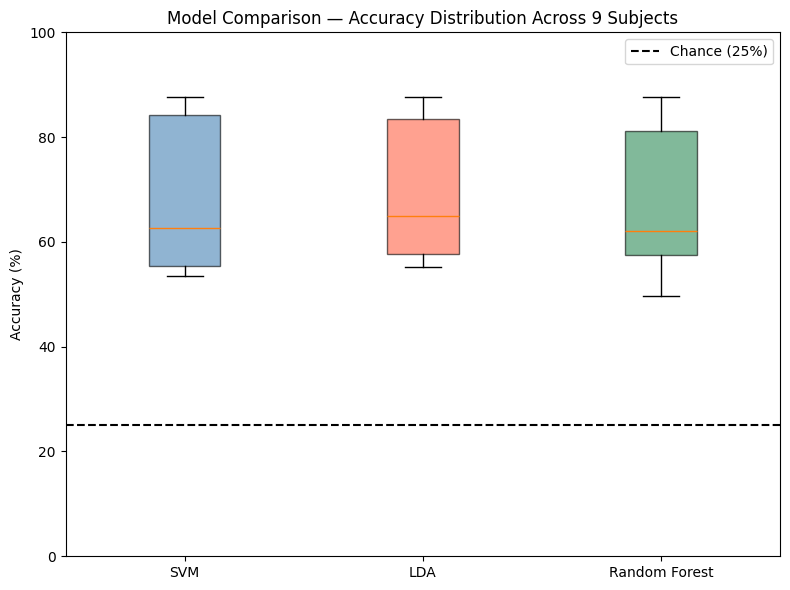

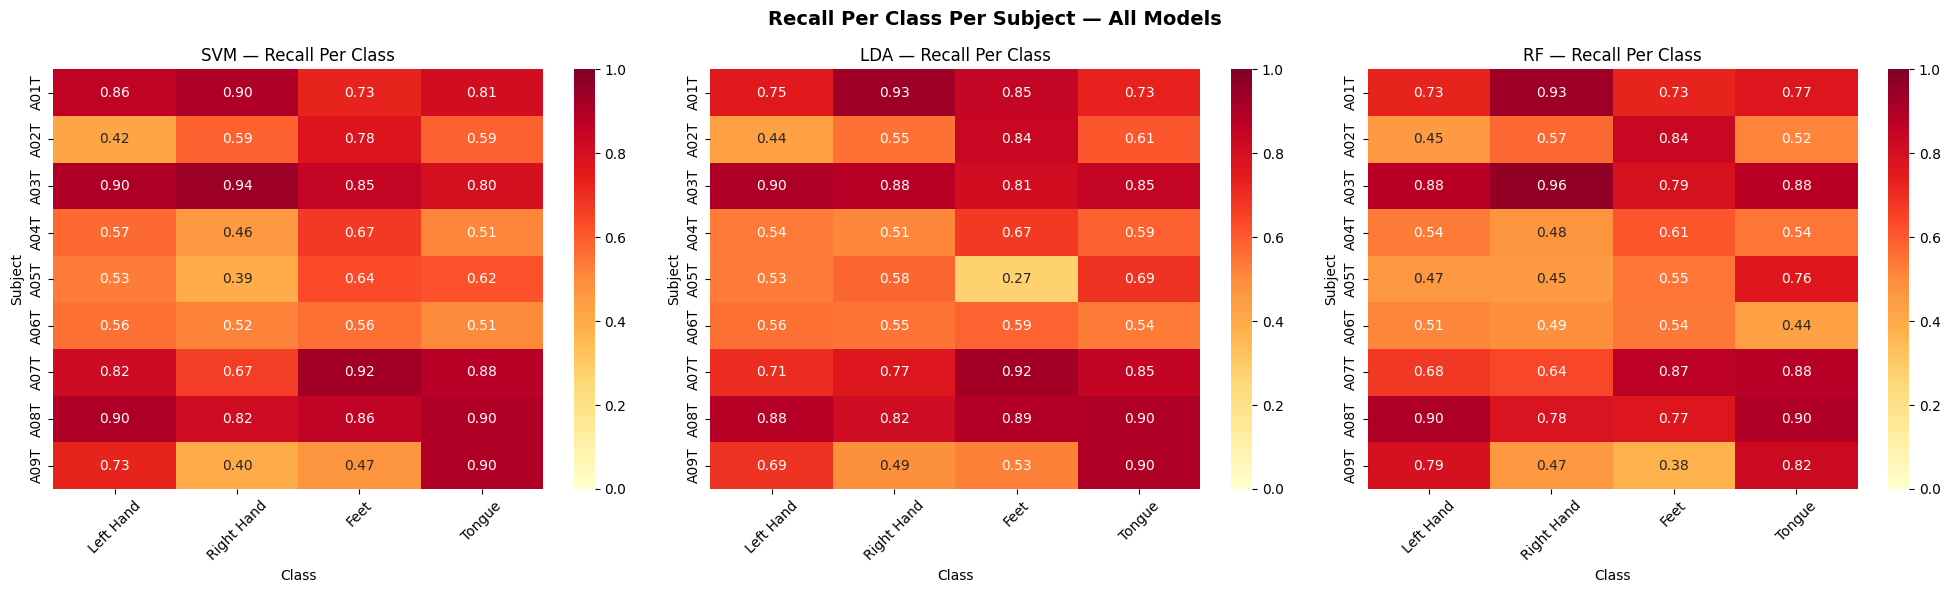

Best subject: A03T — 87.7%


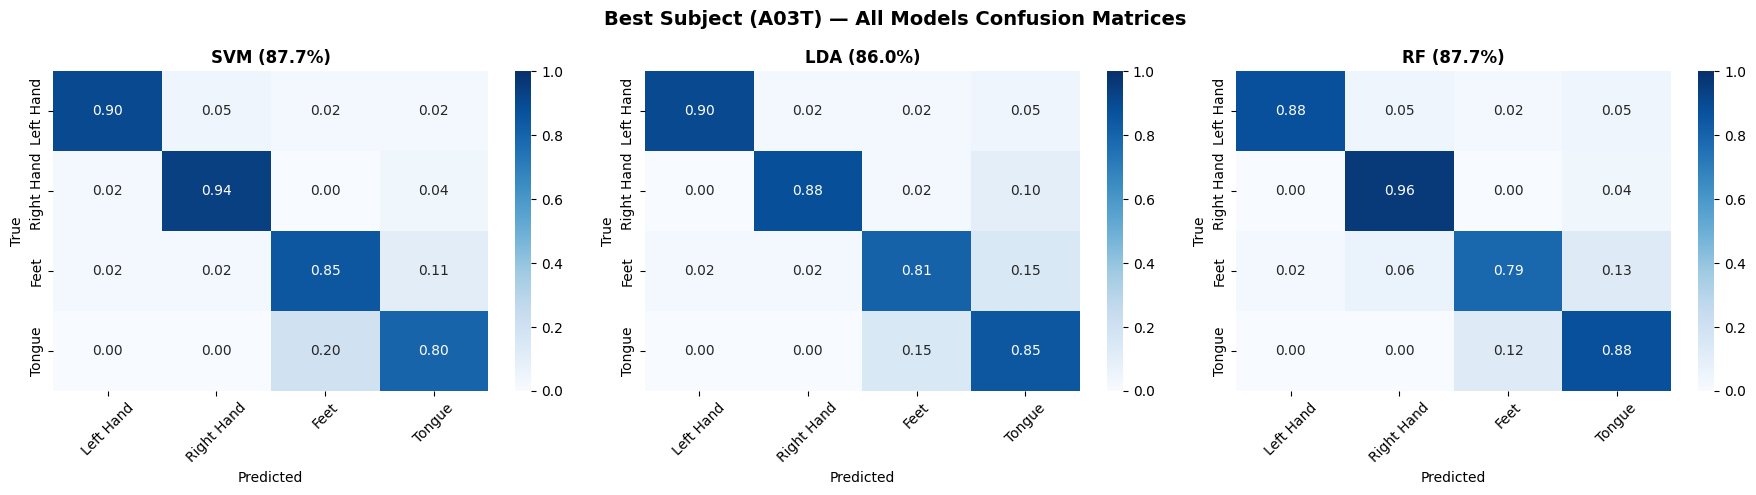

All training visualizations saved.


In [8]:
# Generate all visualizations
run_all_visualizations(all_results, subjects, figures_path=FIGURES_PATH)